In [47]:
import numpy as np
import pandas as pd

In [29]:
#Trained my model
df = pd.read_csv('train.csv')
pd.DataFrame(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df = pd.read_csv('train.csv')
pd.DataFrame(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.drop(['PassengerId','Ticket','Cabin','Name'], axis =1, inplace=True)

In [6]:
df["Age"].fillna(df["Age"].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [7]:
df["Embarked"].fillna(df["Embarked"].mode()[0])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [8]:
df["Sex"]= df["Sex"].map({"male":0, "female":1})

In [9]:
df = pd.get_dummies(df,columns=["Embarked"], drop_first=True)

In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch']
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



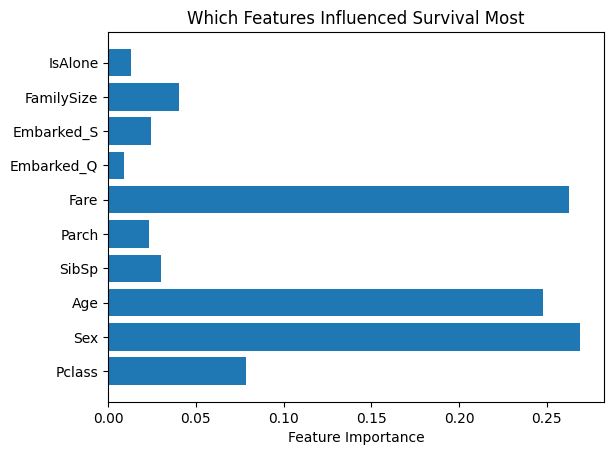

In [12]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.xlabel('Feature Importance')
plt.title('Which Features Influenced Survival Most')
plt.show()


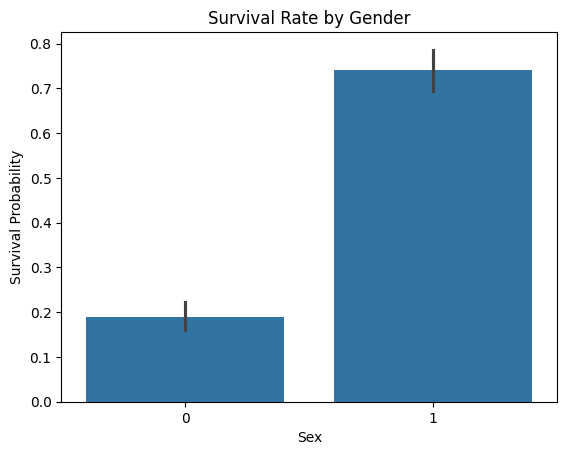

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Probability')
plt.show()


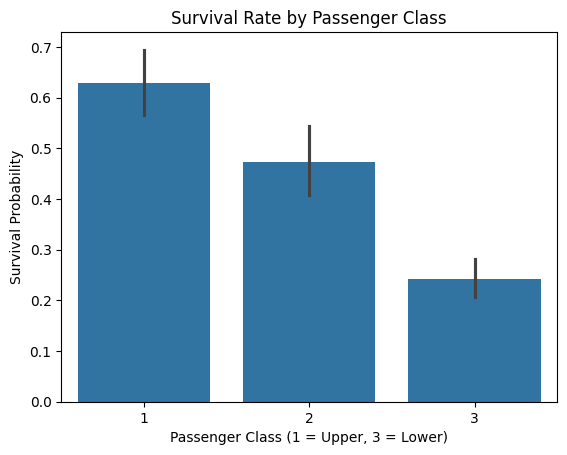

In [14]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = Upper, 3 = Lower)')
plt.ylabel('Survival Probability')
plt.show()


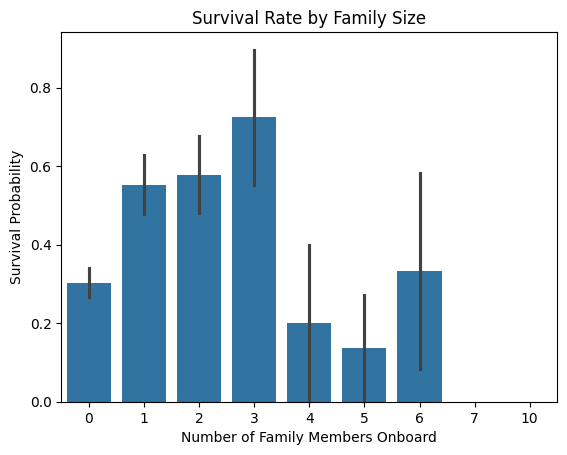

In [15]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.xlabel('Number of Family Members Onboard')
plt.ylabel('Survival Probability')
plt.show()


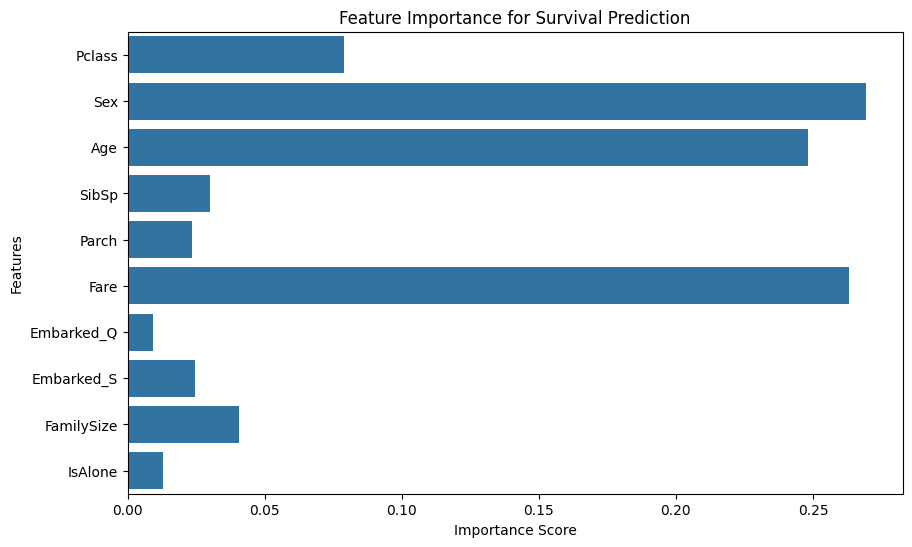

In [16]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance for Survival Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


In [43]:
# Testing the Model
test_df = pd.read_csv('test.csv')
pd.DataFrame(test_df.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [40]:
test_df['Age'].fillna(df['Age'].median())

0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413    28.0
414    39.0
415    38.5
416    28.0
417    28.0
Name: Age, Length: 418, dtype: float64

In [31]:
test_df['Embarked'].fillna(df['Embarked'].mode()[0])

0      Q
1      S
2      Q
3      S
4      S
      ..
413    S
414    C
415    S
416    S
417    C
Name: Embarked, Length: 418, dtype: object

In [32]:
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

In [33]:
test_df = pd.get_dummies(test_df, columns=['Embarked'], drop_first=True)

In [34]:
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch']
test_df['IsAlone'] = (test_df['FamilySize'] == 0).astype(int)

In [35]:
test_df.drop(['PassengerId', 'Ticket', 'Cabin', 'Name'], axis=1, errors='ignore', inplace=True)

In [36]:
predictions = model.predict(test_df)

In [41]:
# Assuming you kept PassengerId
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predictions
})


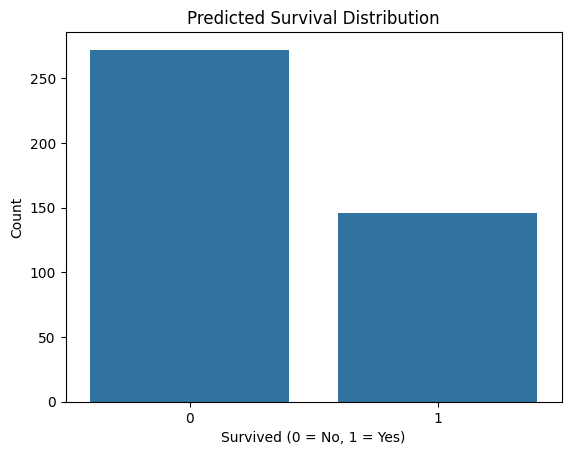

In [42]:
sns.countplot(x=predictions)
plt.title('Predicted Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)  # 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())


Cross-validation scores: [0.79888268 0.80337079 0.86516854 0.7752809  0.84269663]
Average accuracy: 0.817079907099366


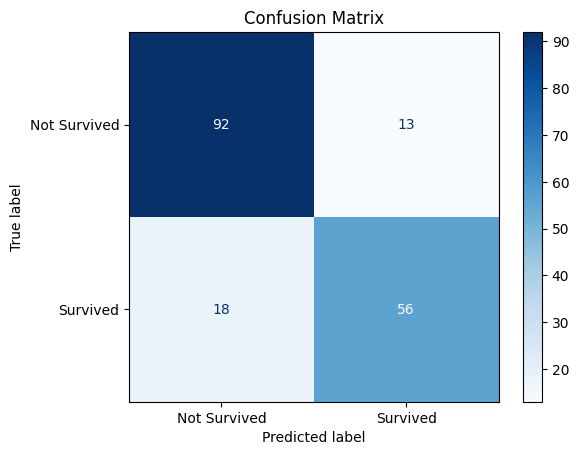

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


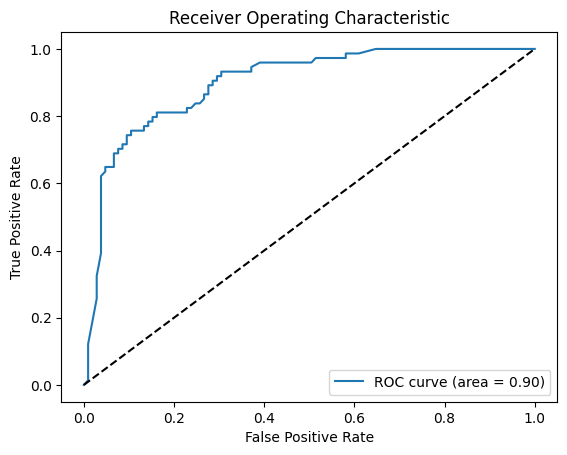

In [46]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.show()


In [54]:
submission.to_csv('titanic_predictions.csv', index=False)

In [49]:
from datetime import datetime

# Generate timestamped filename
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'titanic_predictions_{timestamp}.csv'


In [50]:
# Assuming you have predictions and PassengerId
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predictions
})

# Save to CSV
submission.to_csv(filename, index=False)
print(f"Saved predictions to {filename}")


Saved predictions to titanic_predictions_20251031_231843.csv


In [51]:
def save_predictions_with_timestamp(model, test_df):
    from datetime import datetime
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'titanic_predictions_{timestamp}.csv'
    
    predictions = model.predict(test_df.drop(['PassengerId'], axis=1, errors='ignore'))
    output = pd.DataFrame({
        'PassengerId': test_df['PassengerId'],
        'Survived': predictions
    })
    output.to_csv(filename, index=False)
    print(f"✅ Predictions saved to {filename}")


In [52]:
from sklearn.metrics import accuracy_score

# If you have true labels
accuracy = accuracy_score(y_test, model.predict(X_test))
feature_importance = dict(zip(X.columns, model.feature_importances_))


In [53]:
# Convert metrics to DataFrame
metrics_df = pd.DataFrame({
    'PassengerId': ['Accuracy'] + list(feature_importance.keys()),
    'Survived': [accuracy] + list(feature_importance.values())
})

# Combine both
combined = pd.concat([submission, metrics_df], ignore_index=True)

# Save to CSV
combined.to_csv('titanic_predictions_with_metrics.csv', index=False)
